In [100]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
from torchdiffeq import odeint
import matplotlib.pyplot as plt
from pyro.infer.autoguide.initialization import init_to_value
import numpy as np
print(torch.__version__)

2.13.0


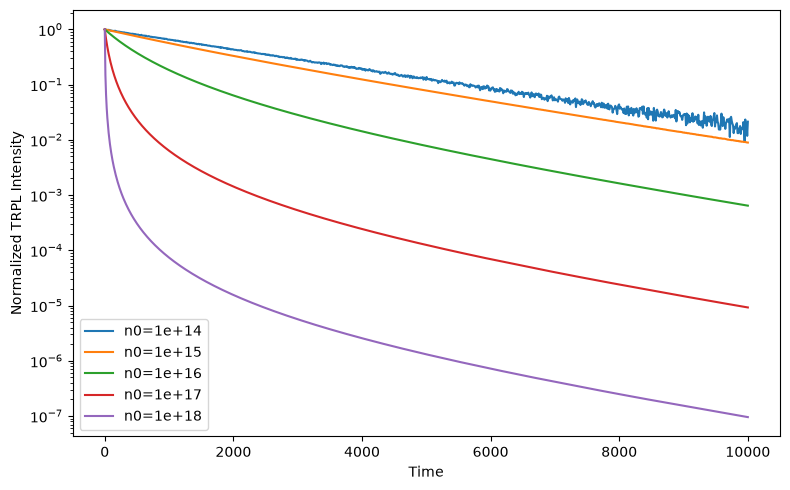

In [75]:
def trpl_ABC(A, B, C, n0s, t):
    # Convert inputs into float64 PyTorch tensors
    A_t = torch.as_tensor(A, dtype=torch.float64)
    B_t = torch.as_tensor(B, dtype=torch.float64)
    C_t = torch.as_tensor(C, dtype=torch.float64)
    n0s_t = torch.as_tensor(n0s, dtype=torch.float64)
    t_t = torch.as_tensor(t, dtype=torch.float64)

    # Differential equation: dn/dt = -A*n - B*n^2 - C*n^3
    def ode_func(t, n):
        return - A_t * n - B_t * (n**2) - C_t * (n**3)

    # odeint solves all elements in n0s_t simultaneously
    n_t = odeint(ode_func, n0s_t, t_t, method='dopri5')  # Shape: [len(t), len(n0s)]

    # TRPL signal is proportional to radiative recombination (n^2)
    return n_t**2

def add_noise(signal, noise_level=0.01):
    # Adds Gaussian noise proportional to the peak signal magnitude
    noise = torch.randn_like(signal) * noise_level
    return signal + noise

# --- Simulation Setup ---
time = torch.linspace(0, 10000, 1000, dtype=torch.float64)
n0s = [1e14, 1e15, 1e16, 1e17, 1e18]

# 1. BATCHED CALL: Solve all n0s simultaneously in a single pass
trpl_signals = trpl_ABC(2e-4, 1e-19, 1e-37, n0s, time)  # Returns tensor of shape [1000, 5]

# 2. Add realistic relative noise (e.g., 2% relative noise)
noisy_signals = add_noise(trpl_signals, noise_level=4e25)

# 3. Plot results
plt.figure(figsize=(8, 5))
for i, n0 in enumerate(n0s):
    # Extract column 'i' corresponding to n0s[i]
    sig = noisy_signals[:, i].numpy()
    sig_norm = sig / sig[0]  # Normalise by t=0 intensity
    plt.plot(time.numpy(), sig_norm, label=f'n0={n0:.0e}')

plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('Normalized TRPL Intensity')
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
# 1. Forward Solver (PyTorch + torchdiffeq)
def forward_trpl(log_A, log_B, log_C, n0s, t, norm=True, log=True):
    # 1. Clamp log parameters to prevent 10**log_X from overflowing float32/float64
    log_A_clamped = torch.clamp(log_A, min=-5.0, max=-3.0)
    log_B_clamped = torch.clamp(log_B, min=-10.5, max=-9.0)
    log_C_clamped = torch.clamp(log_C, min=-38.0, max=-36.0)
    A = 10**log_A#_clamped
    B = 10**log_B#_clamped
    C = 10**log_C#_clamped
    n0s = 10**n0s  # Convert log10(n0s) to n0s
    
    def ode_func(time, n):
        return - A * n - B * (n**2) - C * (n**3)

    n_t = odeint(ode_func, n0s, t, method='dopri5', rtol=1e-6, atol=1e-6, options={"max_num_steps": 10_000})  # Shape: [len(t), len(n0s)]
    trpl_signal = n_t**2  # Signal proportional to n^2

    if log:
        trpl_signal = torch.log(trpl_signal)
    if norm:
        # Divide each fluence column by its respective initial value at t=0
        # trpl_signal[0:1, :] maintains shape (1, num_fluences) for clean broadcasting
        trpl_signal = trpl_signal / trpl_signal[0:1, :]
    return trpl_signal

# 2. Define the Pyro Probabilistic Model
def model(t, n0s, observed_signals=None):
    # Log-space priors
    log_A = pyro.sample("log_A", dist.Normal(-4.0, 0.5))
    log_B = pyro.sample("log_B", dist.Normal(-19.0, 0.5))
    log_C = pyro.sample("log_C", dist.Normal(-37.0, 0.5))
    
    sigma = pyro.sample("sigma", dist.HalfNormal(1e24))

    # mu shape: [len(t), len(n0s)] -> [100, 4]
    mu = forward_trpl(log_A, log_B, log_C, n0s, t, norm=True)

    # Explicitly map dimensions to match mu.shape ([100, 4])
    with pyro.plate("data_time", mu.shape[0], dim=-2):       # dim -2 corresponds to time (100)
        with pyro.plate("data_fluences", mu.shape[1], dim=-1): # dim -1 corresponds to fluences (4)
            pyro.sample("obs", dist.Normal(mu, sigma), obs=observed_signals)

tensor([1.0000e-01, 1.1247e-01, 1.2649e-01, 1.4225e-01, 1.5999e-01, 1.7993e-01,
        2.0236e-01, 2.2758e-01, 2.5595e-01, 2.8786e-01, 3.2375e-01, 3.6410e-01,
        4.0949e-01, 4.6054e-01, 5.1795e-01, 5.8251e-01, 6.5513e-01, 7.3680e-01,
        8.2864e-01, 9.3194e-01, 1.0481e+00, 1.1788e+00, 1.3257e+00, 1.4910e+00,
        1.6768e+00, 1.8859e+00, 2.1210e+00, 2.3853e+00, 2.6827e+00, 3.0171e+00,
        3.3932e+00, 3.8162e+00, 4.2919e+00, 4.8270e+00, 5.4287e+00, 6.1054e+00,
        6.8665e+00, 7.7224e+00, 8.6851e+00, 9.7678e+00, 1.0985e+01, 1.2355e+01,
        1.3895e+01, 1.5627e+01, 1.7575e+01, 1.9766e+01, 2.2230e+01, 2.5001e+01,
        2.8118e+01, 3.1623e+01, 3.5565e+01, 3.9998e+01, 4.4984e+01, 5.0592e+01,
        5.6899e+01, 6.3992e+01, 7.1969e+01, 8.0940e+01, 9.1030e+01, 1.0238e+02,
        1.1514e+02, 1.2949e+02, 1.4563e+02, 1.6379e+02, 1.8421e+02, 2.0717e+02,
        2.3300e+02, 2.6204e+02, 2.9471e+02, 3.3144e+02, 3.7276e+02, 4.1923e+02,
        4.7149e+02, 5.3026e+02, 5.9636e+

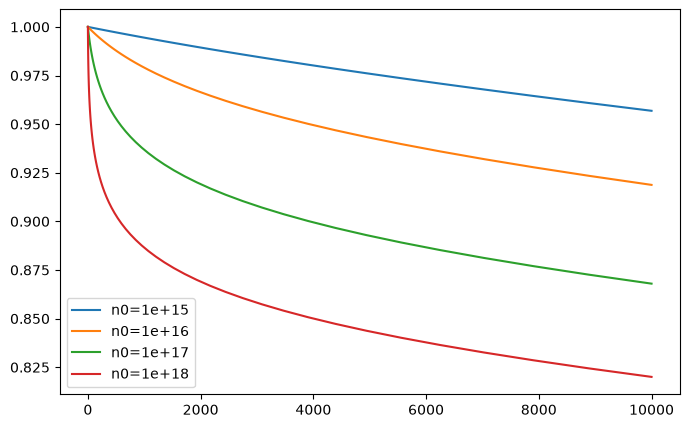

Warmup:   2%|▏         | 32/1500 [03:30,  7.05s/it, step size=5.55e-04, acc. prob=0.718]

In [ ]:
# --- Simulation & HMC Sampling ---

# Synthesise noisy observation data to fit
t_eval = [0] + np.logspace(-1, 4, 99)  # 100 time points for speed
t_eval = torch.tensor(t_eval, dtype=torch.float64)
print(t_eval)
n0s_eval = torch.tensor([15, 16, 17, 18], dtype=torch.float64)

true_log_A = torch.tensor(-4.0, dtype=torch.float64)
true_log_B = torch.tensor(-19.0, dtype=torch.float64)
true_log_C = torch.tensor(-37.0, dtype=torch.float64)

true_signals = forward_trpl(true_log_A, true_log_B, true_log_C, n0s_eval, t_eval, norm=True)
noise_level = 0.00000
observed_data = true_signals + torch.randn_like(true_signals) * noise_level
plt.figure(figsize=(8, 5))
for i, n0 in enumerate(n0s_eval):
    sig = observed_data[:, i].numpy()
    # print(sig[0], sig[-1])
    # sig_norm = sig / sig[0]  # Normalise by t=0 intensity
    plt.plot(t_eval.numpy(), sig, label=f'n0={10**n0:.0e}')
plt.legend()
plt.show()
# Set up NUTS (No-U-Turn Sampler, an adaptive form of HMC)
init_vals = {"log_A": torch.tensor(-4.25), "log_B": torch.tensor(-18.60),
             "log_C": torch.tensor(-36.80), "sigma": torch.tensor(0.1)}
nuts_kernel = NUTS(model, init_strategy=init_to_value(values=init_vals))
mcmc = MCMC(nuts_kernel, num_samples=1000, warmup_steps=500, num_chains=1)

# Run HMC sampling
mcmc.run(t_eval, n0s_eval, observed_data)


In [ ]:

# Extract sampled posterior distributions
prior_samples = mcmc.get_samples()
posterior_samples = mcmc.get_samples()
#show priors and posterioirs in summary
mcmc.summary()



                mean       std    median      5.0%     95.0%     n_eff     r_hat
     log_A     -3.99      0.00     -3.99     -4.00     -3.99      9.92      1.12
     log_B    -19.01      0.00    -19.01    -19.01    -19.00      5.58      1.01
     log_C    -36.74      0.00    -36.74    -36.74    -36.73      4.10      1.59
     sigma      0.00      0.00      0.00      0.00      0.00      3.69      1.66

Number of divergences: 60
